# Importing Libraries and Loading the Dataset

This section imports all the libraries required for data manipulation, visualization, preprocessing, model development, hyperparameter optimization, and model evaluation. The credit risk dataset is then loaded into a pandas DataFrame, and its dimensions along with a sample of records are displayed to understand the structure of the data before further analysis.


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import cross_val_score


In [107]:
data=pd.read_csv('credit_risk_dataset.csv')
print('DATA SHAPE : ',data.shape)
data.sample(10)

DATA SHAPE :  (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1309,23,60996,RENT,0.0,HOMEIMPROVEMENT,E,16000,16.00,1,0.26,N,3
1580,21,35000,RENT,3.0,EDUCATION,A,1500,5.79,0,0.04,N,2
14916,22,120000,MORTGAGE,6.0,EDUCATION,B,8000,12.69,0,0.07,N,2
29475,37,27000,RENT,0.0,MEDICAL,B,1800,11.36,0,0.07,N,11
20318,28,135000,RENT,5.0,VENTURE,B,4000,12.42,0,0.03,N,5
26168,29,97000,OWN,3.0,VENTURE,B,12000,11.83,0,0.12,N,5
24562,32,60000,RENT,4.0,VENTURE,A,10000,7.51,0,0.17,N,9
16850,26,51600,RENT,10.0,EDUCATION,B,14000,10.37,1,0.27,N,2
31113,40,77000,MORTGAGE,9.0,EDUCATION,B,12000,NaN,0,0.16,N,12
5973,23,50004,RENT,3.0,EDUCATION,B,5600,10.59,0,0.11,N,4


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the dataset and identify important relationships between the predictor variables and the target variable. Correlation analysis and categorical visualizations help identify patterns that may influence loan default and provide useful insights before model development.

CORRELATION BETWEEN DATA

This heatmap visualizes the correlation between all numerical features in the dataset. It helps identify the strength and direction of relationships between variables, making it easier to detect highly correlated features and understand how each numerical feature is associated with the target variable (loan_status).

<Axes: >

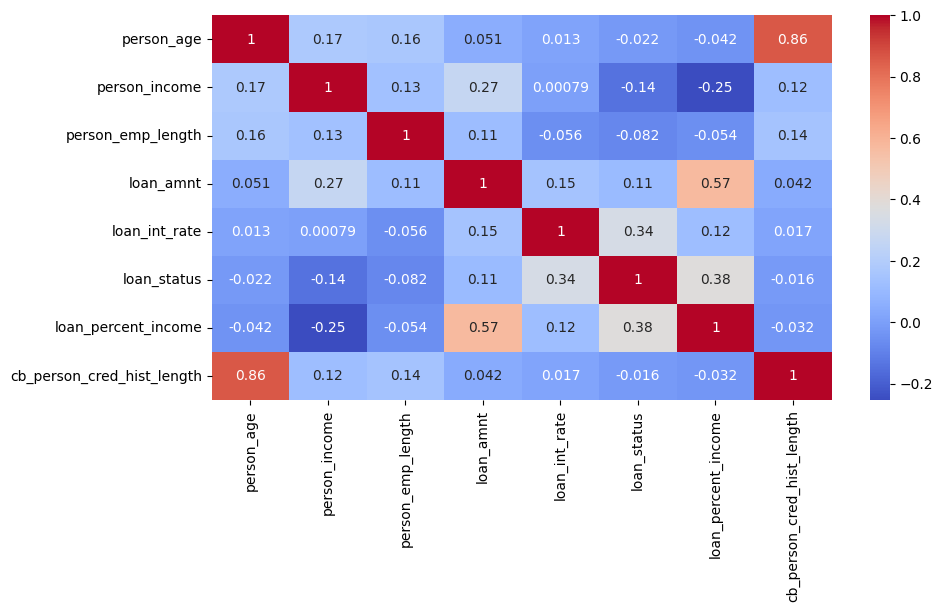

In [108]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [109]:
data.corr(numeric_only=True)['loan_status'].sort_values()

person_income                -0.144449
person_emp_length            -0.082489
person_age                   -0.021629
cb_person_cred_hist_length   -0.015529
loan_amnt                     0.105376
loan_int_rate                 0.335133
loan_percent_income           0.379366
loan_status                   1.000000
Name: loan_status, dtype: float64

RELATION BETWEEN HOME OWNERSHIP AND LOAN STATUS

person_home_ownership
MORTGAGE    12.570663
OTHER       30.841121
OWN          7.469040
RENT        31.569987
Name: loan_status, dtype: float64

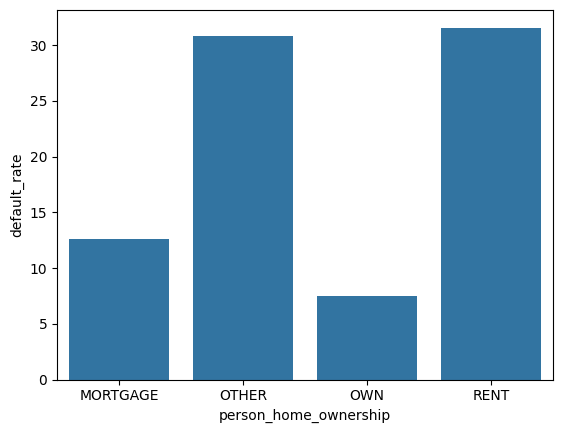

In [110]:


default_rate=data.groupby('person_home_ownership')['loan_status'].mean()*100
sns.barplot(x=default_rate.index,y=default_rate.values)
plt.ylabel("default_rate")
default_rate




This bar chart shows the average loan default rate across different home ownership categories. It helps compare the likelihood of default among borrowers with different housing statuses. In this dataset, borrowers who rent or fall under other ownership categories have higher default rates, while those who own their homes have the lowest default rate.

RELATION BETWEEN LOAN INTENT AND LOAN STATUS

loan_intent
DEBTCONSOLIDATION    28.587874
EDUCATION            17.216798
HOMEIMPROVEMENT      26.102635
MEDICAL              26.700708
PERSONAL             19.887702
VENTURE              14.810282
Name: loan_status, dtype: float64

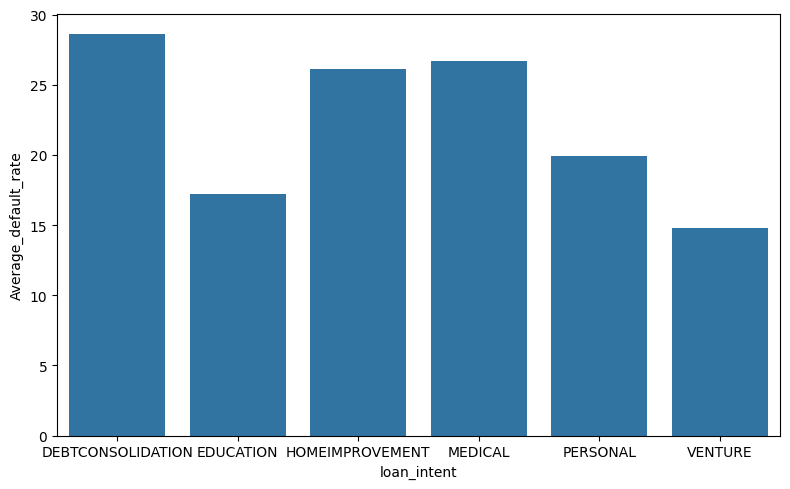

In [111]:
plt.figure(figsize=(8,5))
default_rate=data.groupby('loan_intent')['loan_status'].mean()*100.
sns.barplot(x=default_rate.index,y=default_rate.values)
plt.ylabel("Average_default_rate")
plt.tight_layout()
default_rate




This bar chart illustrates the average loan default rate for different loan purposes. It helps identify which loan intents are associated with a higher risk of default. In this dataset, Debt Consolidation, Medical, and Home Improvement loans have relatively higher default rates, while Venture and Education loans show lower default rates.

RELATION BETWEEN LOAN GRADE AND LOAN DEFAULT

loan_grade
A     9.956389
B    16.275954
C    20.733973
D    59.045780
E    64.419087
F    70.539419
G    98.437500
Name: loan_status, dtype: float64

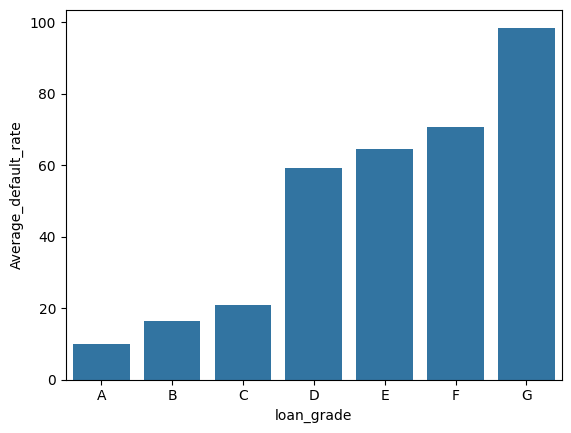

In [112]:


default_rate=data.groupby('loan_grade')['loan_status'].mean()*100.
sns.barplot(x=default_rate.index,y=default_rate.values)
plt.ylabel("Average_default_rate")
default_rate




This bar chart shows the average loan default rate for each loan grade. It illustrates a clear trend where the default rate increases as the loan grade worsens. Borrowers with Grade A loans have the lowest default rate, while Grade G loans have the highest, indicating that lower loan grades are associated with a greater risk of default.

RELATION BETWEEN DEFAULT HISTORY AND LOAN STATUS

cb_person_default_on_file
N    18.393203
Y    37.806789
Name: loan_status, dtype: float64

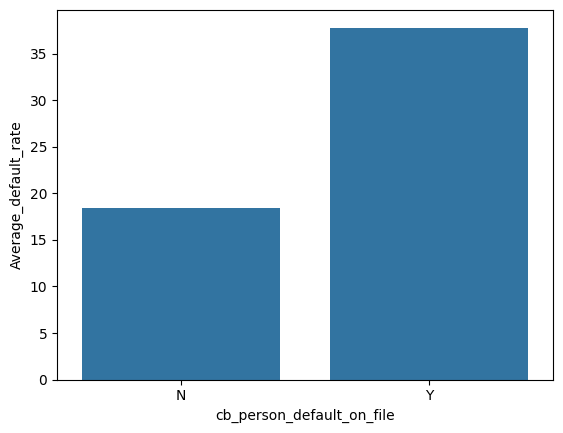

In [113]:


default_rate=data.groupby('cb_person_default_on_file')['loan_status'].mean()*100.
sns.barplot(x=default_rate.index,y=default_rate.values)
plt.ylabel("Average_default_rate")
default_rate




This bar chart compares the average loan default rate based on a borrower's previous default history. It shows that borrowers with a previous default record (Y) have a significantly higher default rate than those with no previous default record (N), indicating that past default history is a strong predictor of future loan default.

# DATA REPORT

Data Profiling

A comprehensive data profiling report can be generated using the ydata-profiling library. This report summarizes missing values, distributions, correlations, duplicate records, and other dataset characteristics, providing an overall understanding of data quality.

In [114]:
from ydata_profiling import ProfileReport
   
prof = ProfileReport(data)

prof.to_file("data_Report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 71.70it/s]


# Data Cleaning

Before building machine learning models, duplicate records are removed to improve data quality. Missing values are handled using median imputation with missing-value indicators to preserve information about missingness while ensuring that the dataset is suitable for model training.

 HANDLING DUPLICATE DATA

In this step we remove all duplicate rows.

In [115]:

data.drop_duplicates(inplace=True)

HANDLING MISSING DATA

Here we calculate how much percentage of data is missing from each column.

In [116]:
(data.isnull().sum() / len(data)) * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.736303
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.547754
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [117]:
x=data.drop(axis=1,columns=['loan_status'])
y=data['loan_status']


In the above step we separate the target column and features columns.

In this step we are splitin the training and testing data.so for training we have 80% of data and 20% for testing.
then we are handling missing values,replacing missing values with median using Simple Imputer.

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=45,stratify=y)
cl=ColumnTransformer(transformers=[
    ('tf1',SimpleImputer(add_indicator=True,strategy="median"),['loan_int_rate','person_emp_length'])
],remainder='passthrough')
x_train=cl.fit_transform(x_train)
x_test=cl.transform(x_test)
cols=cl.get_feature_names_out()





HANDLING OUTLIERS

Outliers are identified using the Interquartile Range (IQR) method. The lower and upper bounds are calculated from the training dataset, and extreme values are capped within these limits. The same thresholds are then applied to the test dataset to prevent data leakage.

In [119]:
outlier_count = {}

for col in data.select_dtypes(include='number').columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count[col] = (
        (data[col] < lower) |
        (data[col] > upper)
    ).sum()

print(pd.DataFrame(
    outlier_count.items(),
    columns=['Column', 'Outlier_Count']
))

                       Column  Outlier_Count
0                  person_age           1491
1               person_income           1478
2           person_emp_length            852
3                   loan_amnt           1679
4               loan_int_rate              6
5                 loan_status           7089
6         loan_percent_income            650
7  cb_person_cred_hist_length           1139


Since we are using column transformer which converts the x_train,x_test into n-dimensional array,so we again convert it into dataframes 
namely x_train_df and x_test_df.

In [120]:
x_train_df=pd.DataFrame(x_train,columns=cols)
x_test_df=pd.DataFrame(x_test,columns=cols)
x_train_df.columns



Index(['tf1__loan_int_rate', 'tf1__person_emp_length',
       'tf1__missingindicator_loan_int_rate',
       'tf1__missingindicator_person_emp_length', 'remainder__person_age',
       'remainder__person_income', 'remainder__person_home_ownership',
       'remainder__loan_intent', 'remainder__loan_grade',
       'remainder__loan_amnt', 'remainder__loan_percent_income',
       'remainder__cb_person_default_on_file',
       'remainder__cb_person_cred_hist_length'],
      dtype='object')

In this step we did capping.

In [121]:
columns=['tf1__loan_int_rate', 'tf1__person_emp_length','remainder__person_age','remainder__person_income','remainder__loan_amnt', 'remainder__loan_percent_income','remainder__cb_person_cred_hist_length']

for col in columns:
    Q1=x_train_df[col].quantile(0.25)
    Q3=x_train_df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    x_train_df[col]=np.where(x_train_df[col]>upper,
                            upper,
                            np.where(x_train_df[col]<lower,
                                     lower,
                                     x_train_df[col]))
    x_test_df[col]=np.where(x_test_df[col]>upper,
                            upper,
                            np.where(x_test_df[col]<lower,
                                     lower,
                                     x_test_df[col]))

Encode categorical variables

Categorical variables are converted into numerical representations suitable for machine learning algorithms. Binary variables are mapped directly, ordinal features are encoded using their natural ordering, and nominal variables are transformed using one-hot encoding while avoiding multicollinearity.

In [122]:
x_train_df['remainder__cb_person_default_on_file']=x_train_df['remainder__cb_person_default_on_file'].map({'Y':1,'N':0})
x_test_df['remainder__cb_person_default_on_file']=x_test_df['remainder__cb_person_default_on_file'].map({'Y':1,'N':0})

In [123]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

cl2=ColumnTransformer(transformers=[
    ('onehot',OneHotEncoder(categories="auto",drop="first",sparse_output=False,handle_unknown="ignore"),['remainder__person_home_ownership','remainder__loan_intent']),
    ('ordinal',OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]),['remainder__loan_grade'])
],remainder="passthrough")
x_train_df=cl2.fit_transform(x_train_df)
x_test_df=cl2.transform(x_test_df)

Since we are using column transformer which converts the x_train,x_test into n-dimensional array,so we again convert it into dataframes 
namely x_train_df1 and x_test_df1

In [124]:

column=cl2.get_feature_names_out()
x_train_df1=pd.DataFrame(x_train_df,columns=column)
x_test_df1=pd.DataFrame(x_test_df,columns=column)
x_train_df1.shape


(25932, 19)

In [125]:
x_train_df1.columns


Index(['onehot__remainder__person_home_ownership_OTHER',
       'onehot__remainder__person_home_ownership_OWN',
       'onehot__remainder__person_home_ownership_RENT',
       'onehot__remainder__loan_intent_EDUCATION',
       'onehot__remainder__loan_intent_HOMEIMPROVEMENT',
       'onehot__remainder__loan_intent_MEDICAL',
       'onehot__remainder__loan_intent_PERSONAL',
       'onehot__remainder__loan_intent_VENTURE',
       'ordinal__remainder__loan_grade', 'remainder__tf1__loan_int_rate',
       'remainder__tf1__person_emp_length',
       'remainder__tf1__missingindicator_loan_int_rate',
       'remainder__tf1__missingindicator_person_emp_length',
       'remainder__remainder__person_age',
       'remainder__remainder__person_income',
       'remainder__remainder__loan_amnt',
       'remainder__remainder__loan_percent_income',
       'remainder__remainder__cb_person_default_on_file',
       'remainder__remainder__cb_person_cred_hist_length'],
      dtype='object')

In [126]:
numeric_cols=['remainder__tf1__person_emp_length',
             'remainder__remainder__person_age', 'remainder__remainder__person_income',
       'remainder__remainder__loan_amnt','remainder__remainder__loan_percent_income','remainder__remainder__cb_person_cred_hist_length', 'remainder__tf1__loan_int_rate']

Feature Scaling

The numerical features are normalized using Min-Max Scaling so that all variables have comparable ranges. Scaling improves the performance of distance-based algorithms and ensures that no single feature dominates the learning process due to its larger numerical scale.

In [127]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_df1[numeric_cols] = scaler.fit_transform(x_train_df1[numeric_cols])
x_test_df1[numeric_cols] = scaler.transform(x_test_df1[numeric_cols])



# MODEL EVALUATION FUNCTION

A reusable evaluation function is created to ensure consistent assessment of all classification models. The function trains the model, predicts probabilities, applies a customizable classification threshold, and calculates multiple evaluation metrics including Accuracy, Precision, Recall, F1-score, ROC-AUC, and Precision-Recall AUC. It also generates the ROC curve, Precision-Recall curve, and confusion matrix for visual performance analysis.

In [128]:


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,accuracy_score, precision_score, recall_score, f1_score
)

def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5,
    model_name=None,
    show_curves=True
):

    # Train model
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    report = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )
    ).transpose()

    cm = confusion_matrix(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    # Model name
    if model_name is None:
        model_name = model.__class__.__name__

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("\nClassification Report\n")
    print(report)

    print(f"\nROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")

    print("\nConfusion Matrix\n")
    print(pd.DataFrame(
        cm,
        index=["Actual 0","Actual 1"],
        columns=["Predicted 0","Predicted 1"]
    ))

    if show_curves:

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)

        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, linewidth=2,
                 label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} ROC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(
            y_test,
            y_prob
        )

        plt.figure(figsize=(6,5))
        plt.plot(recall, precision,
                 linewidth=2,
                 label=f"AP = {pr_auc:.3f}")

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{model_name} Precision-Recall Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        "model": model,
    "classification_report": report,
    "confusion_matrix": cm,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "probabilities": y_prob,
    "predictions": y_pred
    }

# Model 1 : LOGISTIC REGRESSION

Logistic Regression is implemented as the baseline classification algorithm for predicting loan default. Hyperparameter optimization is performed using Optuna with five-fold cross-validation to identify the optimal model configuration. The optimized model is then evaluated using the proposed evaluation framework.


In [129]:
from sklearn.linear_model import LogisticRegression

def objective_lr(trial):
    C=trial.suggest_float("C",0.1,0.9)
    solver=trial.suggest_categorical("solver",['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'])
    max_iter=trial.suggest_int("max_iter",100,5000)
    model=LogisticRegression(class_weight={0:1,1:3},solver=solver,C=C,max_iter=max_iter,random_state=42)  
    score=cross_val_score(model,x_train_df1,y_train,scoring="average_precision",cv=5).mean()
    return score
lr_study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
lr_study.optimize(objective_lr, n_trials=50)

print(lr_study.best_params)
print(lr_study.best_value)


[I 2026-07-01 00:27:47,618] A new study created in memory with name: no-name-359c4193-8689-416f-840c-1157921cd321
[I 2026-07-01 00:27:48,007] Trial 0 finished with value: 0.70406314456108 and parameters: {'C': 0.39963209507789, 'solver': 'lbfgs', 'max_iter': 4345}. Best is trial 0 with value: 0.70406314456108.
[I 2026-07-01 00:27:48,413] Trial 1 finished with value: 0.7041940128180655 and parameters: {'C': 0.5808920093945671, 'solver': 'newton-cg', 'max_iter': 998}. Best is trial 1 with value: 0.7041940128180655.
[I 2026-07-01 00:27:48,820] Trial 2 finished with value: 0.7040398984179188 and parameters: {'C': 0.3433937943676302, 'solver': 'newton-cholesky', 'max_iter': 1895}. Best is trial 1 with value: 0.7041940128180655.
[I 2026-07-01 00:27:49,362] Trial 3 finished with value: 0.704149357785783 and parameters: {'C': 0.46485598737362877, 'solver': 'lbfgs', 'max_iter': 935}. Best is trial 1 with value: 0.7041940128180655.
[I 2026-07-01 00:27:49,866] Trial 4 finished with value: 0.70315

{'C': 0.8638492803853285, 'solver': 'saga', 'max_iter': 4997}
0.7043556978851552


Logistic Regression

Classification Report

              precision    recall  f1-score    support
0              0.896417  0.908804  0.902568  5066.0000
1              0.657270  0.624824  0.640636  1418.0000
accuracy       0.846700  0.846700  0.846700     0.8467
macro avg      0.776844  0.766814  0.771602  6484.0000
weighted avg   0.844118  0.846700  0.845286  6484.0000

ROC-AUC : 0.8693
PR-AUC  : 0.7098

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4604          462
Actual 1          532          886


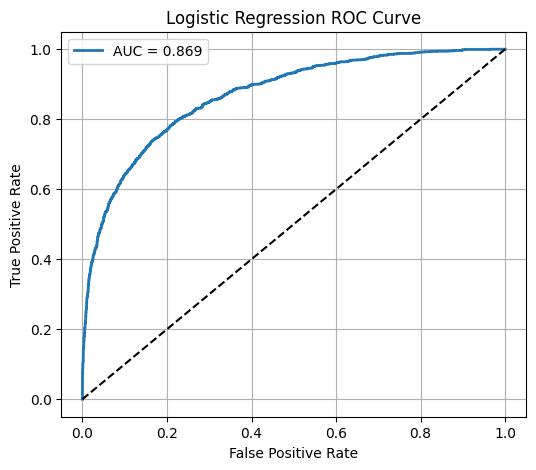

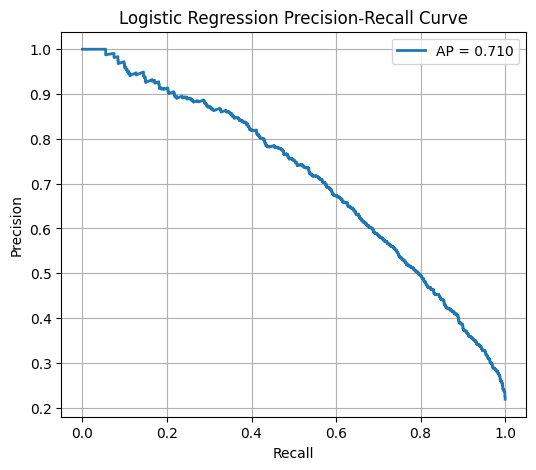

In [130]:
best_tune=lr_study.best_params
lr = LogisticRegression(
    **best_tune,
    class_weight={0:1,1:3},
    random_state=42
)

results = evaluate_model(
    lr,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.65,
    model_name="Logistic Regression"
)

Threshold Optimization

Instead of using the default classification threshold of 0.5, different threshold values are evaluated to determine the threshold that maximizes the F1-score. This process improves the balance between precision and recall, which is particularly important for imbalanced classification problems.

In [131]:

# Get probabilities from the evaluation function
y_prob = results["probabilities"]

thresholds = np.arange(0.10, 1.00, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_results = pd.DataFrame(threshold_results)

print(threshold_results)

    Threshold  Precision    Recall  F1 Score
0        0.10   0.282688  0.978843  0.438685
1        0.15   0.318353  0.954161  0.477417
2        0.20   0.351569  0.924542  0.509423
3        0.25   0.383298  0.899859  0.537603
4        0.30   0.416948  0.870945  0.563927
5        0.35   0.447388  0.845557  0.585163
6        0.40   0.477612  0.812412  0.601567
7        0.45   0.514727  0.776446  0.619061
8        0.50   0.549193  0.744006  0.631926
9        0.55   0.580326  0.703103  0.635842
10       0.60   0.613342  0.667842  0.639433
11       0.65   0.657270  0.624824  0.640636
12       0.70   0.698630  0.575458  0.631090
13       0.75   0.743802  0.507757  0.603521
14       0.80   0.789948  0.432299  0.558797
15       0.85   0.854949  0.353315  0.500000
16       0.90   0.889724  0.250353  0.390754
17       0.95   0.945652  0.122708  0.217228


This plot compares Precision, Recall, and F1 Score across different probability thresholds. It helps identify the threshold that provides the best balance between correctly detecting defaulters and minimizing incorrect predictions, allowing the selection of the optimal classification threshold.

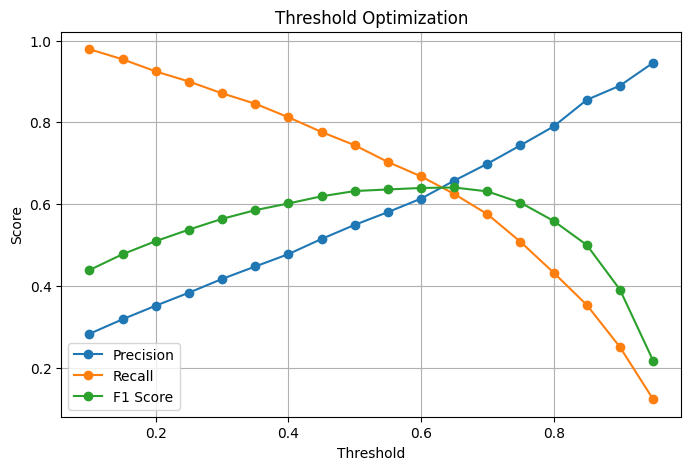

In [132]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.grid(True)
plt.legend()

plt.show()

This code identifies the probability threshold that achieves the highest F1 Score from the evaluated thresholds. It then displays the corresponding threshold along with its Precision, Recall, and F1 Score, helping select the optimal threshold for the final model

In [133]:
best_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

print("="*40)
print("Best Threshold Based on F1 Score")
print("="*40)

print(f"Threshold : {best_row['Threshold']:.2f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1 Score  : {best_row['F1 Score']:.4f}")

Best Threshold Based on F1 Score
Threshold : 0.65
Precision : 0.6573
Recall    : 0.6248
F1 Score  : 0.6406


# Model 2 : K-Nearest Neighbors (KNN)

The K-Nearest Neighbors algorithm classifies borrowers based on the similarity between observations. Optuna is used to optimize the number of neighbors and weighting strategy, after which the optimized model is evaluated using the common evaluation framework.

In [134]:
from sklearn.neighbors import KNeighborsClassifier
def objective_knn(trial):
    n_neighbors=trial.suggest_int("n_neighbors",5,25)
    weights=trial.suggest_categorical("weights",['uniform', 'distance'])
    model1=KNeighborsClassifier(weights=weights,n_neighbors=n_neighbors)
    score=cross_val_score(model1,x_train_df1,y_train,cv=5,scoring="average_precision").mean()
    return score
knn_study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
knn_study.optimize(objective_knn, n_trials=50)

[I 2026-07-01 00:28:14,026] A new study created in memory with name: no-name-5becbbe9-f434-44a6-b895-0f03376260ef
[I 2026-07-01 00:28:15,058] Trial 0 finished with value: 0.766661527564199 and parameters: {'n_neighbors': 12, 'weights': 'uniform'}. Best is trial 0 with value: 0.766661527564199.
[I 2026-07-01 00:28:16,071] Trial 1 finished with value: 0.7717862634758242 and parameters: {'n_neighbors': 17, 'weights': 'uniform'}. Best is trial 1 with value: 0.7717862634758242.
[I 2026-07-01 00:28:16,915] Trial 2 finished with value: 0.7422516553015441 and parameters: {'n_neighbors': 6, 'weights': 'uniform'}. Best is trial 1 with value: 0.7717862634758242.
[I 2026-07-01 00:28:18,286] Trial 3 finished with value: 0.7971641403046975 and parameters: {'n_neighbors': 19, 'weights': 'distance'}. Best is trial 3 with value: 0.7971641403046975.
[I 2026-07-01 00:28:19,693] Trial 4 finished with value: 0.7739294974371198 and parameters: {'n_neighbors': 22, 'weights': 'uniform'}. Best is trial 3 with 

In [135]:
best_parameters=knn_study.best_params
print(knn_study.best_value)

0.7975145433682772


KNN

Classification Report

              precision    recall  f1-score      support
0              0.892614  0.982827  0.935551  5066.000000
1              0.903974  0.577574  0.704819  1418.000000
accuracy       0.894201  0.894201  0.894201     0.894201
macro avg      0.898294  0.780200  0.820185  6484.000000
weighted avg   0.895098  0.894201  0.885091  6484.000000

ROC-AUC : 0.8908
PR-AUC  : 0.8051

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4979           87
Actual 1          599          819


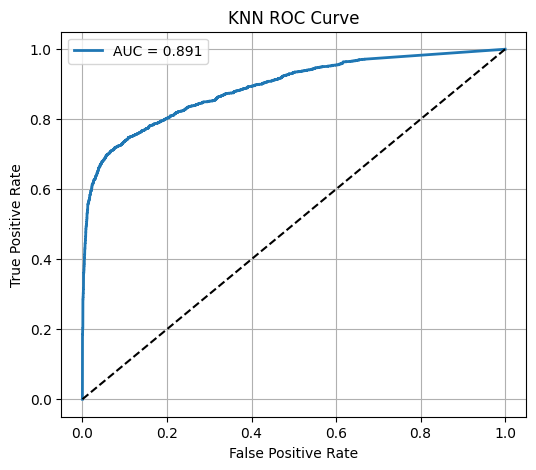

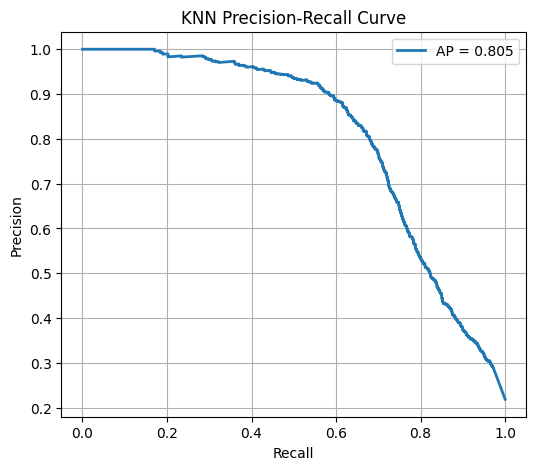

{'model': KNeighborsClassifier(n_neighbors=20, weights='distance'),
 'classification_report':               precision    recall  f1-score      support
 0              0.892614  0.982827  0.935551  5066.000000
 1              0.903974  0.577574  0.704819  1418.000000
 accuracy       0.894201  0.894201  0.894201     0.894201
 macro avg      0.898294  0.780200  0.820185  6484.000000
 weighted avg   0.895098  0.894201  0.885091  6484.000000,
 'confusion_matrix': array([[4979,   87],
        [ 599,  819]]),
 'roc_auc': 0.8907924563602477,
 'pr_auc': 0.8050869393367903,
 'accuracy': 0.8942011104256632,
 'precision': 0.9039735099337748,
 'recall': 0.577574047954866,
 'f1_score': 0.7048192771084337,
 'probabilities': array([0.39634759, 0.10052004, 0.09481994, ..., 0.25088089, 0.23714948,
        0.2012615 ], shape=(6484,)),
 'predictions': array([0, 0, 0, ..., 0, 0, 0], shape=(6484,))}

In [136]:
knn = KNeighborsClassifier(**best_parameters)

evaluate_model(
    knn,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.50,
    model_name="KNN"
)

# Model 3 : DECISION TREE

The Decision Tree classifier models nonlinear decision boundaries by recursively splitting the feature space. Hyperparameters controlling tree complexity are optimized using Optuna to improve predictive performance while reducing overfitting.

In [137]:
from sklearn.tree import DecisionTreeClassifier

def objective_dt(trial):
    criterion=trial.suggest_categorical("criterion",["gini","entropy","log_loss"])
    splitter=trial.suggest_categorical("splitter",["best","random"])
    max_depth=trial.suggest_int("max_depth",1,20)
    min_samples_split=trial.suggest_int("min_samples_split",200,2000)
    max_features=trial.suggest_categorical("max_features",["sqrt","log2"])
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 50, 500)
  


    
    dt=DecisionTreeClassifier(random_state=42,criterion=criterion,max_depth=max_depth,splitter=splitter,min_samples_leaf=min_samples_leaf,max_features=max_features,min_samples_split=min_samples_split)
    score=cross_val_score(dt,x_train_df1,y_train,cv=5,scoring="average_precision").mean()
    return score
dt_study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
dt_study.optimize(objective_dt,n_trials=200)

[I 2026-07-01 00:30:28,145] A new study created in memory with name: no-name-e0473d35-f27c-40a3-8366-24bb7f2ca605
[I 2026-07-01 00:30:28,534] Trial 0 finished with value: 0.5674391099728242 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 4, 'min_samples_split': 304, 'max_features': 'sqrt', 'min_samples_leaf': 369}. Best is trial 0 with value: 0.5674391099728242.
[I 2026-07-01 00:30:28,900] Trial 1 finished with value: 0.5798490249759032 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 4, 'min_samples_split': 747, 'max_features': 'sqrt', 'min_samples_leaf': 181}. Best is trial 1 with value: 0.5798490249759032.
[I 2026-07-01 00:30:29,266] Trial 2 finished with value: 0.6192106382918696 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 16, 'min_samples_split': 559, 'max_features': 'log2', 'min_samples_leaf': 70}. Best is trial 2 with value: 0.6192106382918696.
[I 2026-07-01 00:30:29,633] Trial 3 finished with value:

Decision Tree

Classification Report

              precision    recall  f1-score      support
0              0.917185  0.931307  0.924192  5066.000000
1              0.740299  0.699577  0.719362  1418.000000
accuracy       0.880629  0.880629  0.880629     0.880629
macro avg      0.828742  0.815442  0.821777  6484.000000
weighted avg   0.878501  0.880629  0.879397  6484.000000

ROC-AUC : 0.8978
PR-AUC  : 0.7926

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4718          348
Actual 1          426          992


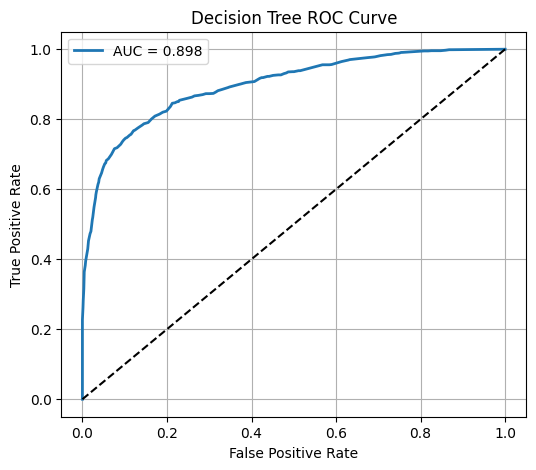

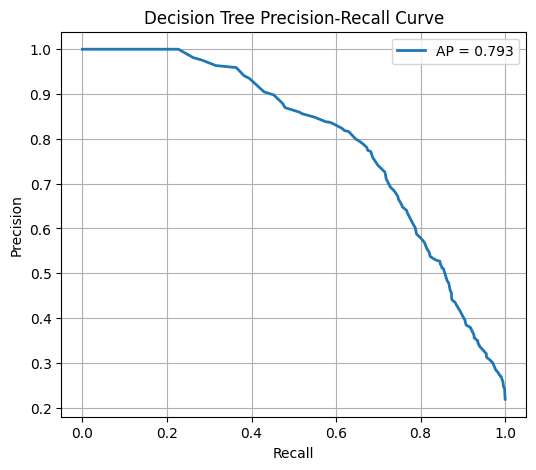

In [138]:

best_hyper_parameters=dt_study.best_params
dt=DecisionTreeClassifier(**best_hyper_parameters,random_state=42, class_weight={0:1, 1:2})
results = evaluate_model(
    dt,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.5,
    model_name="Decision Tree"
)


# Model 4 : RANDOM FOREST

Random Forest combines multiple decision trees to improve prediction accuracy and reduce variance. Optuna is used to optimize important hyperparameters such as tree depth, number of trees, bootstrap sampling, and feature selection strategy before evaluating the final model.

In [139]:
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    n_estimators=trial.suggest_int("n_estimators",50,200)
    criterion=trial.suggest_categorical("criterion",["gini","entropy","log_loss"])
    max_depth=trial.suggest_int("max_depth",5,25)
    min_samples_leaf=trial.suggest_int("min_samples_leaf",20,500)
    min_samples_split=trial.suggest_int("min_samples_split",20,500)
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    if bootstrap:
       max_samples = trial.suggest_float(
        "max_samples",
        0.5,
        1.0
    )
    else:
       max_samples = None
   

    max_features=trial.suggest_categorical("max_features",["sqrt","log2"])
    rf=RandomForestClassifier(n_jobs=-1,n_estimators=n_estimators,criterion=criterion,max_depth=max_depth,max_features=max_features,min_samples_leaf=min_samples_leaf,
                              min_samples_split=min_samples_split,bootstrap=bootstrap,max_samples=max_samples,random_state=42)
    score=cross_val_score(rf,x_train_df1,y_train,cv=5,scoring="average_precision").mean()
    return score

rf_study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(objective_rf,n_trials=50)


[I 2026-07-01 00:32:10,999] A new study created in memory with name: no-name-db035a88-187d-41ed-b772-839698d5990b
[I 2026-07-01 00:32:18,806] Trial 0 finished with value: 0.8444131908984531 and parameters: {'n_estimators': 106, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 95, 'min_samples_split': 47, 'bootstrap': True, 'max_samples': 0.8540362888980227, 'max_features': 'log2'}. Best is trial 0 with value: 0.8444131908984531.
[I 2026-07-01 00:32:34,927] Trial 1 finished with value: 0.8319595320864959 and parameters: {'n_estimators': 175, 'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 272, 'min_samples_split': 227, 'bootstrap': False, 'max_features': 'log2'}. Best is trial 0 with value: 0.8444131908984531.
[I 2026-07-01 00:32:41,591] Trial 2 finished with value: 0.7895541522982658 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 304, 'min_samples_split': 42, 'bootstrap': True, 'max_samples': 0.5325257964926398, 'max

0.8715835863591556
Random Forest

Classification Report

              precision    recall  f1-score      support
0              0.931733  0.980655  0.955568  5066.000000
1              0.914931  0.743300  0.820233  1418.000000
accuracy       0.928748  0.928748  0.928748     0.928748
macro avg      0.923332  0.861978  0.887901  6484.000000
weighted avg   0.928058  0.928748  0.925972  6484.000000

ROC-AUC : 0.9310
PR-AUC  : 0.8805

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4968           98
Actual 1          364         1054


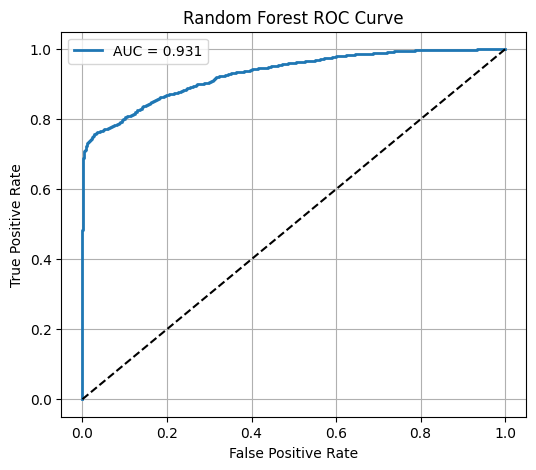

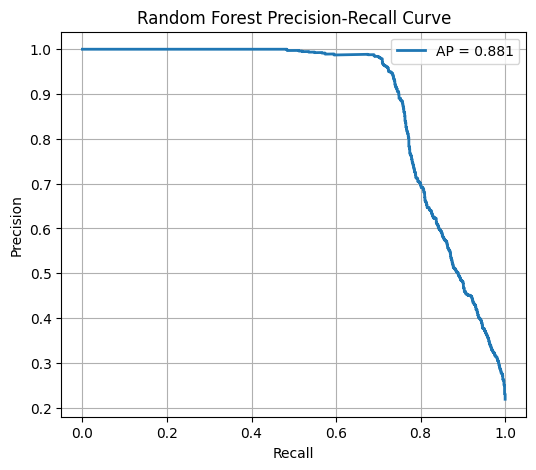

{'model': RandomForestClassifier(bootstrap=False, criterion='log_loss', max_depth=20,
                        min_samples_leaf=23, min_samples_split=82,
                        n_estimators=186, n_jobs=-1, random_state=42),
 'classification_report':               precision    recall  f1-score      support
 0              0.931733  0.980655  0.955568  5066.000000
 1              0.914931  0.743300  0.820233  1418.000000
 accuracy       0.928748  0.928748  0.928748     0.928748
 macro avg      0.923332  0.861978  0.887901  6484.000000
 weighted avg   0.928058  0.928748  0.925972  6484.000000,
 'confusion_matrix': array([[4968,   98],
        [ 364, 1054]]),
 'roc_auc': 0.9309744656848361,
 'pr_auc': 0.8805449137879563,
 'accuracy': 0.9287476866132017,
 'precision': 0.9149305555555556,
 'recall': 0.7433004231311706,
 'f1_score': 0.8202334630350194,
 'probabilities': array([0.13164446, 0.03463631, 0.04171444, ..., 0.92970206, 0.09136861,
        0.80632564], shape=(6484,)),
 'predictions':

In [140]:

best_params=rf_study.best_params
print(rf_study.best_value)

rf = RandomForestClassifier(n_jobs=-1,
    **best_params,
    random_state=42
)

evaluate_model(
    rf,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.40,
    model_name="Random Forest"
)

# Model 5 : VOTING

A soft Voting Classifier combines the predictions of multiple optimized base learners including Logistic Regression, KNN, Decision Tree, and Random Forest. The final prediction is obtained by averaging the predicted probabilities of all constituent models, resulting in a more robust ensemble classifier.

Voting Classifier

Classification Report

              precision    recall  f1-score      support
0              0.912054  0.988749  0.948854  5066.000000
1              0.942540  0.659379  0.775934  1418.000000
accuracy       0.916718  0.916718  0.916718     0.916718
macro avg      0.927297  0.824064  0.862394  6484.000000
weighted avg   0.918721  0.916718  0.911038  6484.000000

ROC-AUC : 0.9203
PR-AUC  : 0.8561

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         5009           57
Actual 1          483          935


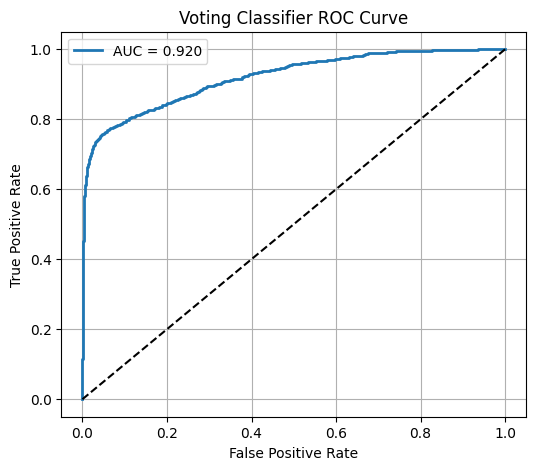

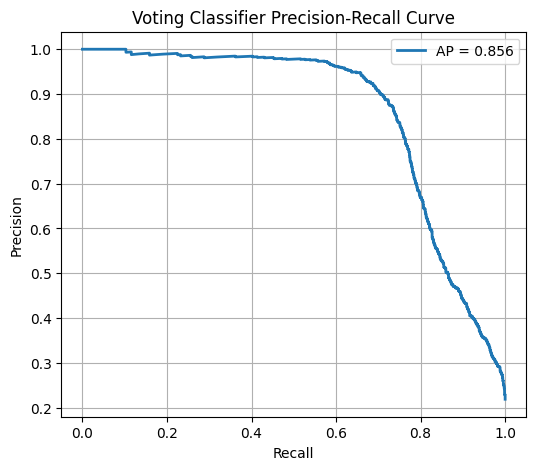

{'model': VotingClassifier(estimators=[('cl1',
                               RandomForestClassifier(bootstrap=False,
                                                      criterion='log_loss',
                                                      max_depth=20,
                                                      min_samples_leaf=23,
                                                      min_samples_split=82,
                                                      n_estimators=186,
                                                      random_state=42)),
                              ('cl2',
                               LogisticRegression(C=0.8638492803853285,
                                                  class_weight={0: 1, 1: 3},
                                                  max_iter=4997, random_state=42,
                                                  solver='saga')),
                              ('cl3',
                               KNeighborsClassifier(n_neighbors=20,


In [141]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier



rf_final = RandomForestClassifier(
    **rf_study.best_params,      
    random_state=42              
)                                 

lr_final = LogisticRegression(
    **lr_study.best_params,
    class_weight={0: 1, 1: 3},   
    random_state=42
)

knn_final = KNeighborsClassifier(**knn_study.best_params)

dt_final = DecisionTreeClassifier(
    **dt_study.best_params,
    class_weight={0: 1, 1: 2},
    random_state=42              
)

estimators = [
    ("cl1", rf_final),
    ("cl2", lr_final),
    ("cl3", knn_final),
    ("cl4", dt_final),
]

voting = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)

evaluate_model(
    voting, x_train_df1, y_train, x_test_df1, y_test,
    threshold=0.60, model_name="Voting Classifier"
)

# Model 6 : XGBOOST

Extreme Gradient Boosting (XGBoost) is implemented as an advanced ensemble learning algorithm capable of modeling complex nonlinear relationships. The model incorporates class imbalance handling using the scale_pos_weight parameter and is evaluated using multiple performance metrics.

XGBoost

Classification Report

              precision    recall  f1-score      support
0              0.941602  0.977102  0.959024  5066.000000
1              0.905460  0.783498  0.840076  1418.000000
accuracy       0.934762  0.934762  0.934762     0.934762
macro avg      0.923531  0.880300  0.899550  6484.000000
weighted avg   0.933698  0.934762  0.933011  6484.000000

ROC-AUC : 0.9505
PR-AUC  : 0.9114

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4950          116
Actual 1          307         1111


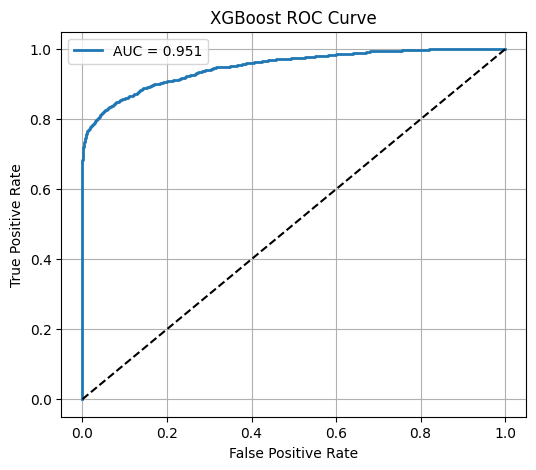

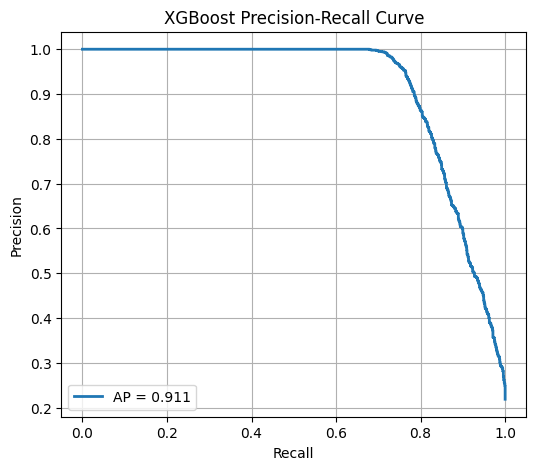

{'model': XGBClassifier(base_score=None, booster='dart', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.6846096357558054, device=None,
               early_stopping_rounds=None, enable_categorical=True,
               eval_metric='logloss', feature_types=None, feature_weights=None,
               gamma=0, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.33292878939099235,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=8, max_leaves=None,
               min_child_weight=1, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=153, n_jobs=None,
               num_parallel_tree=None, ...),
 'classification_report':               precision    recall  f1-score      support
 0              0.941602  0.977102  0.959024  5066.000000
 1              0.905460  0.783498  0

In [142]:
from xgboost import XGBClassifier

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

xgb = XGBClassifier(
    booster='dart',
    learning_rate=0.33292878939099235,
    gamma=0,
    max_depth=8,
    n_estimators=153,
    subsample=0.9770196494996333,
    colsample_bytree=0.6846096357558054,
    reg_lambda=17,
    reg_alpha=2,
    min_child_weight=1,
    tree_method="hist",
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

evaluate_model(
    xgb,
    x_train_df1.astype(float),
    y_train,
    x_test_df1.astype(float),
    y_test,
    threshold=0.61,
    model_name="XGBoost"
)




# SHAP Explainability

SHAP (SHapley Additive exPlanations) is applied to interpret the predictions of the XGBoost model. Global and local explanation techniques, including Beeswarm, Waterfall, and SHAP feature importance plots, are used to understand how individual features influence the model's predictions.

In [143]:

import shap

explainer = shap.TreeExplainer(
    xgb,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(
    x_test_df1.astype(float)
)



SHAP Beeswarm Plot

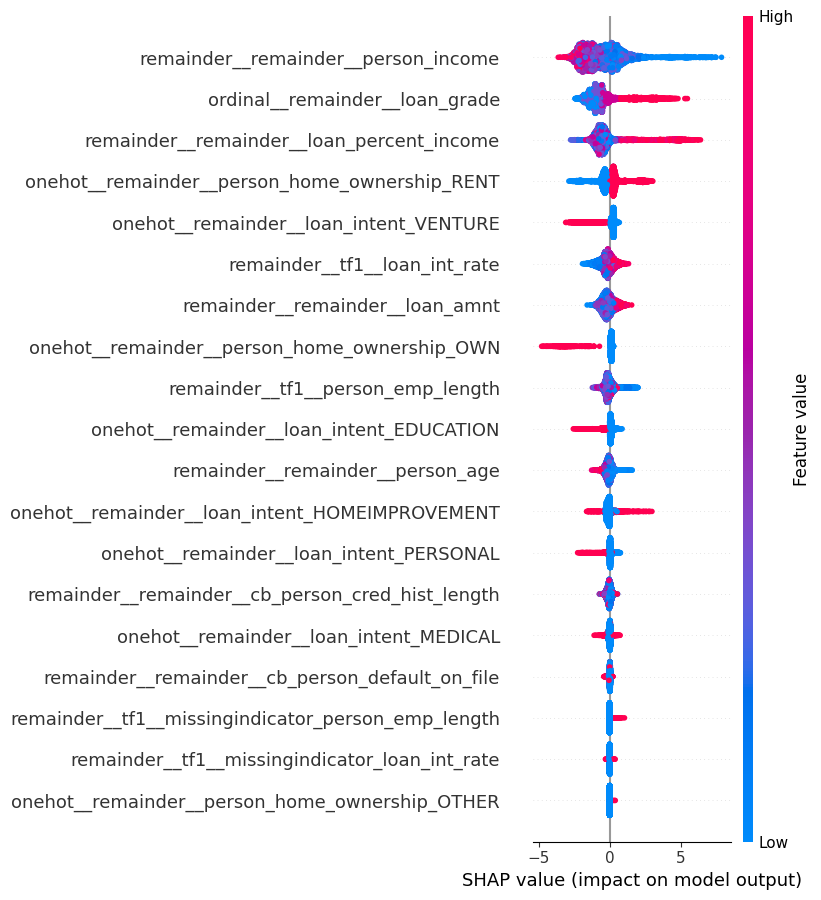

In [144]:
shap.summary_plot(
    shap_values,
    x_test_df1.astype(float)
)

This SHAP summary plot shows the overall importance of each feature and its influence on the model's predictions. Features at the top have the greatest impact, with person income, loan grade, and loan percent income being the most influential. The color indicates the feature value (low to high), while the horizontal position shows whether the feature increases or decreases the predicted risk of loan default

WATERFALL PLOT

c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_mathtext.py:2170: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_mathtext.py:2197: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyparsing\util.py:439: DeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\_mathtext.py:2178: DeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


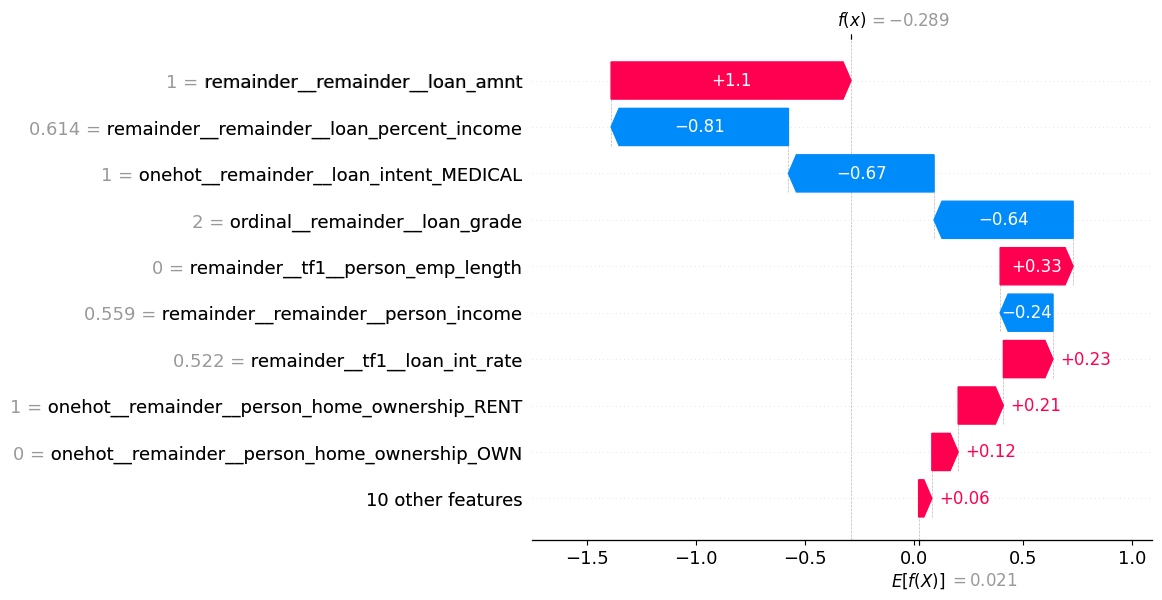

In [145]:
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=x_test_df1.astype(float).values,
    feature_names=x_test_df1.columns
)
shap.plots.waterfall(shap_exp[0])

This SHAP waterfall plot explains how individual feature values contribute to a single prediction. Each feature either increases (red) or decreases (blue) the model's prediction, with the combined contributions producing the final output. In this example, loan percent income, person income, and loan grade have the strongest influence on the prediction, while other features have smaller impacts.

SHAP BAR PLOT

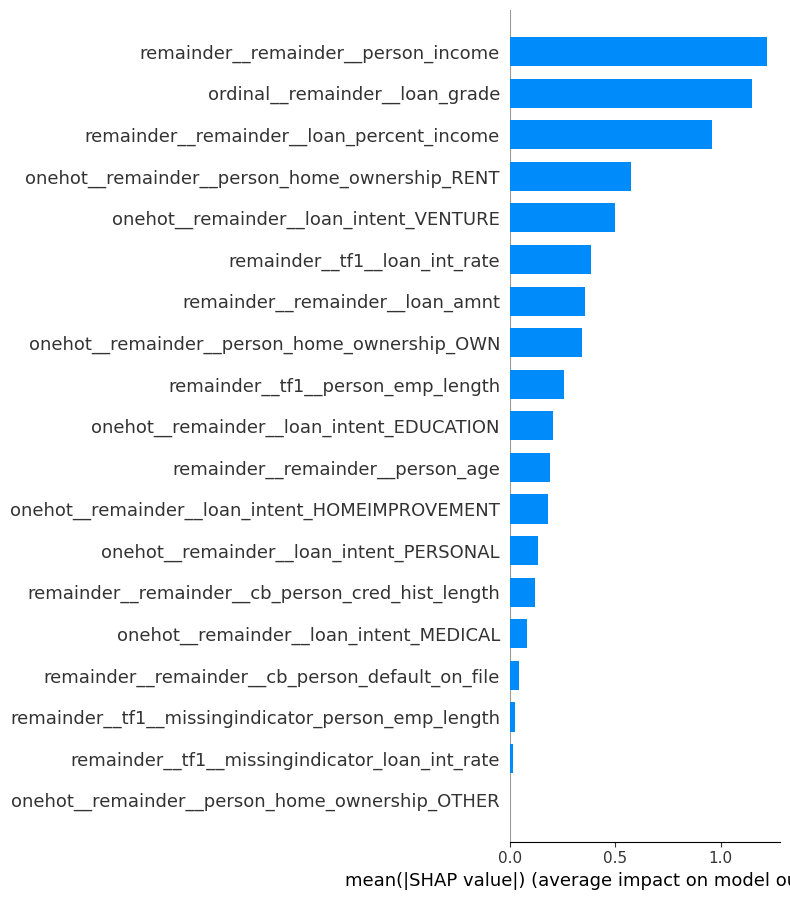

In [146]:
shap.summary_plot(
    shap_values,
    x_test_df1.astype(float),
    plot_type="bar"
)

This SHAP feature importance plot ranks features based on their average impact on the model's predictions. Features with higher mean absolute SHAP values contribute more to the model's decisions. In this model, person income, loan grade, and loan percent income are the most influential features, while the remaining features have comparatively smaller effects.

Feature Importance Analysis

Feature importance is analyzed using the gain-based importance scores produced by XGBoost. This analysis identifies the variables that contribute most significantly to loan default prediction and provides additional insight into the model's decision-making process.

<Figure size 1000x800 with 0 Axes>

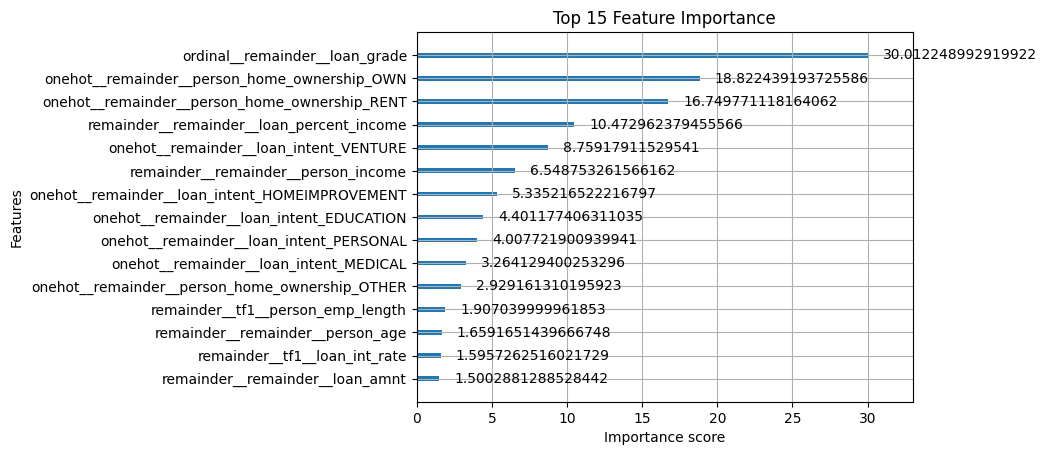

In [147]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    xgb,
    max_num_features=15,
    importance_type="gain"
)

plt.title("Top 15 Feature Importance")
plt.show()

This feature importance plot ranks the top 15 features based on their contribution to the XGBoost model. Features with higher importance scores have a greater influence on the model's predictions. In this model, loan grade, home ownership (RENT), and home ownership (OWN) are the most important features, while the remaining features have relatively lower importance.

# Model 7 : LightGBM

LightGBM is implemented as an efficient gradient boosting algorithm designed for high predictive performance and faster training. Optuna is used to optimize its hyperparameters through cross-validation, and feature importance scores are generated to understand the contribution of each predictor.

In [148]:
from lightgbm import LGBMClassifier


from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {
         "class_weight": {
            0: 1,
            1: trial.suggest_float(
                "class1_weight",
                1.0,
                5.0
            )
        },
        "min_child_samples": trial.suggest_int(
    "min_child_samples",
    10,
    100
    ),
    "min_split_gain": trial.suggest_float(
    "min_split_gain",
    0.0,
    1.0
    ),

        "learning_rate":
        trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "n_estimators":
        trial.suggest_int(
            "n_estimators",
            50,
            300
        ),

        "max_depth":
        trial.suggest_int(
            "max_depth",
            3,
            15
        ),

        "num_leaves":
        trial.suggest_int(
            "num_leaves",
            20,
            150
        ),

        "subsample":
        trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree":
        trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "reg_lambda":
        trial.suggest_float(
            "reg_lambda",
            0,
            10
        )
        
    }

    model = LGBMClassifier(
        **params,verbosity=-1,
        random_state=42,
    )

    score = cross_val_score(
        model,
        x_train_df1.astype(float),
        y_train,
        scoring="average_precision",
        cv=cv
    ).mean()

    return score

light_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

light_study.optimize(objective,n_trials=50)

print(light_study.best_params)

[I 2026-07-01 00:43:01,363] A new study created in memory with name: no-name-ee911897-4d56-4ff7-ad9d-f451d22f4c51
[I 2026-07-01 00:43:03,186] Trial 0 finished with value: 0.8813688521858063 and parameters: {'class1_weight': 2.49816047538945, 'min_child_samples': 96, 'min_split_gain': 0.7319939418114051, 'learning_rate': 0.07661100707771368, 'n_estimators': 89, 'max_depth': 5, 'num_leaves': 27, 'subsample': 0.9330880728874675, 'colsample_bytree': 0.8005575058716043, 'reg_lambda': 7.080725777960454}. Best is trial 0 with value: 0.8813688521858063.
[I 2026-07-01 00:43:06,262] Trial 1 finished with value: 0.8618556413251474 and parameters: {'class1_weight': 1.0823379771832098, 'min_child_samples': 98, 'min_split_gain': 0.8324426408004217, 'learning_rate': 0.020589728197687916, 'n_estimators': 95, 'max_depth': 5, 'num_leaves': 59, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'reg_lambda': 2.9122914019804194}. Best is trial 0 with value: 0.8813688521858063.
[I 2026

{'class1_weight': 3.927673216937906, 'min_child_samples': 16, 'min_split_gain': 0.0029854944992842025, 'learning_rate': 0.10303138209298475, 'n_estimators': 247, 'max_depth': 8, 'num_leaves': 149, 'subsample': 0.5877829402995346, 'colsample_bytree': 0.6679616951813591, 'reg_lambda': 4.050033223349056}


LightGBM

Classification Report

              precision    recall  f1-score      support
0              0.940103  0.975918  0.957676  5066.000000
1              0.900408  0.777856  0.834658  1418.000000
accuracy       0.932603  0.932603  0.932603     0.932603
macro avg      0.920255  0.876887  0.896167  6484.000000
weighted avg   0.931422  0.932603  0.930772  6484.000000

ROC-AUC : 0.9522
PR-AUC  : 0.9114

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4944          122
Actual 1          315         1103


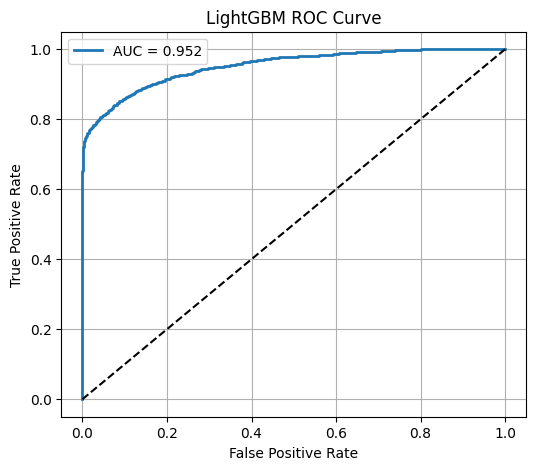

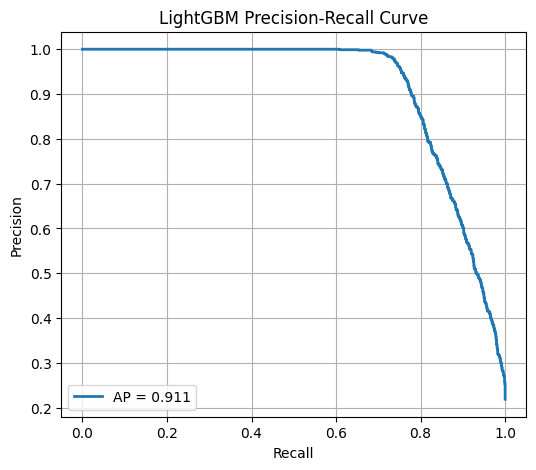

{'model': LGBMClassifier(class_weight={0: 1, 1: 3.927673216937906},
                colsample_bytree=0.6679616951813591,
                learning_rate=0.10303138209298475, max_depth=8,
                min_child_samples=16, min_split_gain=0.0029854944992842025,
                n_estimators=247, num_leaves=149, random_state=42,
                reg_lambda=4.050033223349056, subsample=0.5877829402995346),
 'classification_report':               precision    recall  f1-score      support
 0              0.940103  0.975918  0.957676  5066.000000
 1              0.900408  0.777856  0.834658  1418.000000
 accuracy       0.932603  0.932603  0.932603     0.932603
 macro avg      0.920255  0.876887  0.896167  6484.000000
 weighted avg   0.931422  0.932603  0.930772  6484.000000,
 'confusion_matrix': array([[4944,  122],
        [ 315, 1103]]),
 'roc_auc': 0.9522036898552644,
 'pr_auc': 0.9113855969104253,
 'accuracy': 0.9326033312769895,
 'precision': 0.9004081632653061,
 'recall': 0.777856135401

In [149]:
best_tuned=light_study.best_params
class1_weight = best_tuned.pop("class1_weight")
lgbm = LGBMClassifier(
    **best_tuned,
    random_state=42,
    class_weight={0: 1, 1: class1_weight}
)

evaluate_model(
    lgbm,
    x_train_df1.astype(float),
    y_train,
    x_test_df1.astype(float),
    y_test,
    threshold=0.61,
    model_name="LightGBM"
)

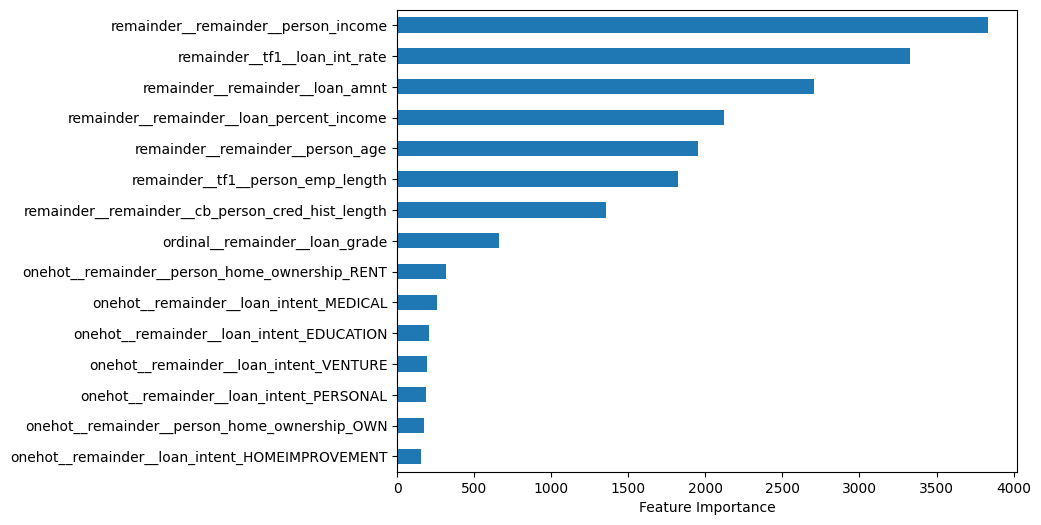

In [150]:

importance = pd.Series(
    lgbm.feature_importances_,
    index=x_train_df1.columns
).sort_values()

importance.tail(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.xlabel("Feature Importance")
plt.show()

This feature importance plot ranks the top features based on their contribution to the LightGBM model. Features with higher importance values have a greater influence on the model's predictions. In this model, person income, loan interest rate, and loan amount are the most influential features, while the remaining features have a relatively smaller impact on predicting loan default.

# Model 8 : Balanced Random Forest

Balanced Random Forest addresses the class imbalance problem by constructing balanced bootstrap samples for each decision tree. Hyperparameter optimization is performed using Optuna, and the resulting model is evaluated using the same metrics applied to the other classification algorithms.


In [151]:
from imblearn.ensemble import BalancedRandomForestClassifier

def objective(trial):
    n_estimators=trial.suggest_int("n_estimators",50,200)
    criterion=trial.suggest_categorical("criterion",["gini","entropy","log_loss"])
    max_depth=trial.suggest_int("max_depth",5,25)
    min_samples_leaf=trial.suggest_int("min_samples_leaf",20,500)
    min_samples_split=trial.suggest_int("min_samples_split",20,500)
    bootstrap=trial.suggest_categorical("bootstrap",[True,False])
    max_samples = trial.suggest_float(
    "max_samples",
    0.5,
    1.0
)
    replacement = trial.suggest_categorical(
    "replacement",
    [True, False]
)
    sampling_strategy = trial.suggest_categorical(
    "sampling_strategy",
    ["auto", "all"]
)
    max_features=trial.suggest_categorical("max_features",["sqrt","log2"])
    brf=BalancedRandomForestClassifier(n_jobs=-1,n_estimators=n_estimators,sampling_strategy=sampling_strategy,replacement=replacement,max_samples=max_samples,criterion=criterion,max_depth=max_depth,max_features=max_features,min_samples_leaf=min_samples_leaf,min_samples_split=min_samples_split,bootstrap=bootstrap,random_state=42)
    score=cross_val_score(brf,x_train_df1,y_train,cv=5,scoring="average_precision").mean()
    return score

brf_study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
brf_study.optimize(objective,n_trials=50)



[I 2026-07-01 00:55:26,495] A new study created in memory with name: no-name-92bc69d3-1c2b-4e79-8d6e-8c2586e8c6b4
[I 2026-07-01 00:55:41,175] Trial 0 finished with value: 0.8207100847051263 and parameters: {'n_estimators': 106, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 95, 'min_samples_split': 47, 'bootstrap': True, 'max_samples': 0.8540362888980227, 'replacement': False, 'sampling_strategy': 'auto', 'max_features': 'log2'}. Best is trial 0 with value: 0.8207100847051263.
[I 2026-07-01 00:55:52,847] Trial 1 finished with value: 0.8401632840539831 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'max_depth': 17, 'min_samples_leaf': 87, 'min_samples_split': 160, 'bootstrap': False, 'max_samples': 0.8925879806965068, 'replacement': False, 'sampling_strategy': 'auto', 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8401632840539831.
[I 2026-07-01 00:56:01,053] Trial 2 finished with value: 0.8267347248855501 and parameters: {'n_estimators': 59, 'criterion': 'e

Balanced Random Forest

Classification Report

              precision    recall  f1-score      support
0              0.932940  0.966640  0.949491  5066.000000
1              0.863158  0.751763  0.803619  1418.000000
accuracy       0.919648  0.919648  0.919648     0.919648
macro avg      0.898049  0.859202  0.876555  6484.000000
weighted avg   0.917679  0.919648  0.917590  6484.000000

ROC-AUC : 0.9288
PR-AUC  : 0.8755

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4897          169
Actual 1          352         1066


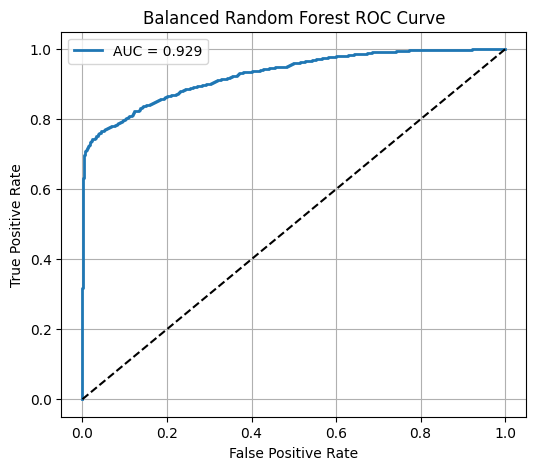

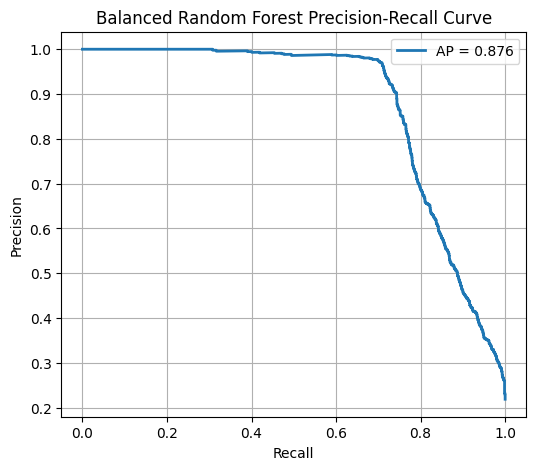

{'model': BalancedRandomForestClassifier(criterion='entropy', max_depth=15,
                                max_samples=0.9241388140125207,
                                min_samples_leaf=20, min_samples_split=60,
                                n_estimators=164, n_jobs=-1, random_state=42,
                                replacement=False, sampling_strategy='auto'),
 'classification_report':               precision    recall  f1-score      support
 0              0.932940  0.966640  0.949491  5066.000000
 1              0.863158  0.751763  0.803619  1418.000000
 accuracy       0.919648  0.919648  0.919648     0.919648
 macro avg      0.898049  0.859202  0.876555  6484.000000
 weighted avg   0.917679  0.919648  0.917590  6484.000000,
 'confusion_matrix': array([[4897,  169],
        [ 352, 1066]]),
 'roc_auc': 0.928807999567904,
 'pr_auc': 0.8755396651082991,
 'accuracy': 0.9196483652066626,
 'precision': 0.8631578947368421,
 'recall': 0.7517630465444288,
 'f1_score': 0.80361854504334

In [152]:
best_params=brf_study.best_params
brf = BalancedRandomForestClassifier(n_jobs=-1,
    **best_params,
    random_state=42
)

evaluate_model(
    brf,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.62,
    model_name="Balanced Random Forest"
)

# Models Comparision

Logistic Regression

Classification Report

              precision    recall  f1-score    support
0              0.896417  0.908804  0.902568  5066.0000
1              0.657270  0.624824  0.640636  1418.0000
accuracy       0.846700  0.846700  0.846700     0.8467
macro avg      0.776844  0.766814  0.771602  6484.0000
weighted avg   0.844118  0.846700  0.845286  6484.0000

ROC-AUC : 0.8693
PR-AUC  : 0.7098

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4604          462
Actual 1          532          886


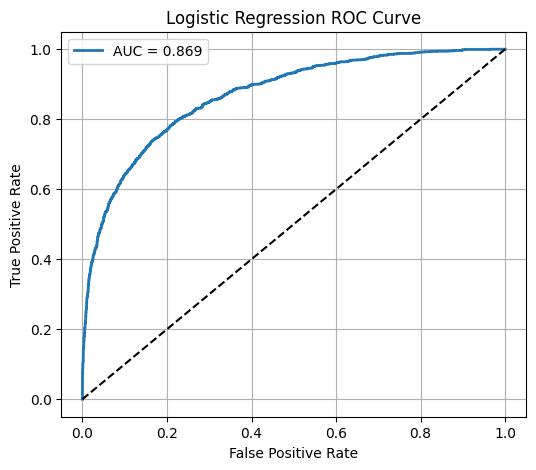

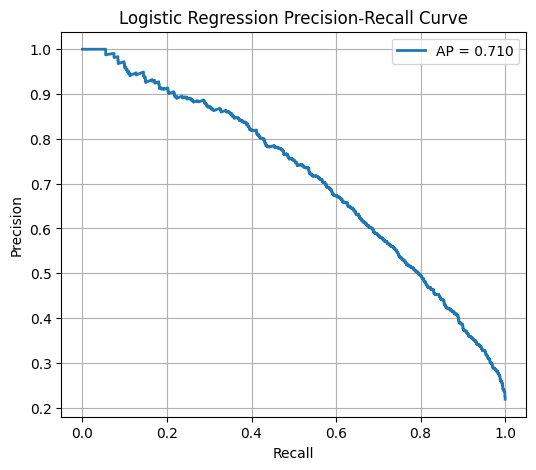

KNN

Classification Report

              precision    recall  f1-score      support
0              0.892614  0.982827  0.935551  5066.000000
1              0.903974  0.577574  0.704819  1418.000000
accuracy       0.894201  0.894201  0.894201     0.894201
macro avg      0.898294  0.780200  0.820185  6484.000000
weighted avg   0.895098  0.894201  0.885091  6484.000000

ROC-AUC : 0.8908
PR-AUC  : 0.8051

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4979           87
Actual 1          599          819


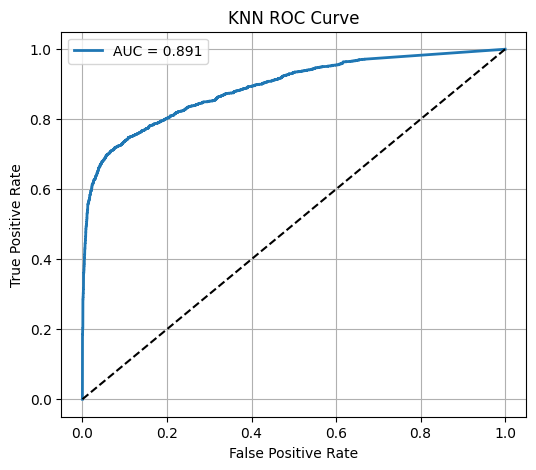

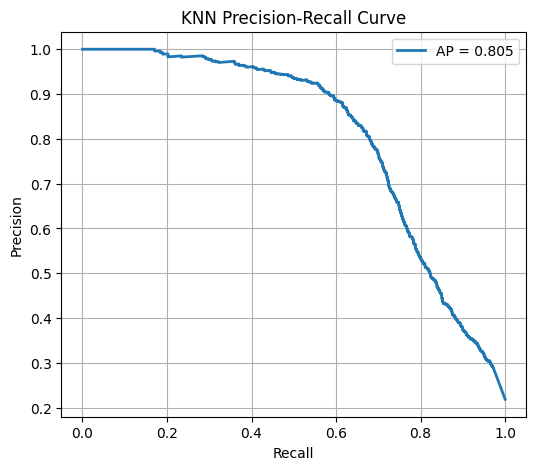

Decision Tree

Classification Report

              precision    recall  f1-score      support
0              0.917185  0.931307  0.924192  5066.000000
1              0.740299  0.699577  0.719362  1418.000000
accuracy       0.880629  0.880629  0.880629     0.880629
macro avg      0.828742  0.815442  0.821777  6484.000000
weighted avg   0.878501  0.880629  0.879397  6484.000000

ROC-AUC : 0.8978
PR-AUC  : 0.7926

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4718          348
Actual 1          426          992


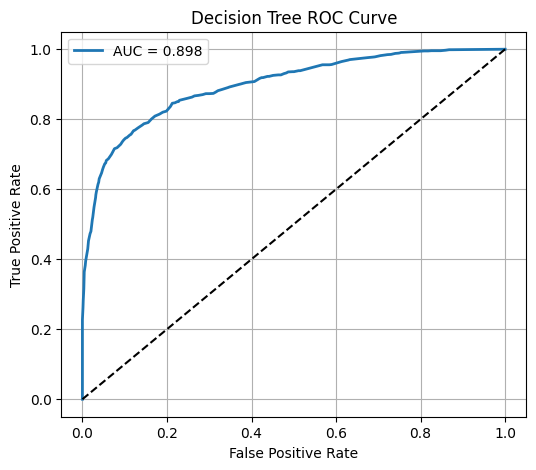

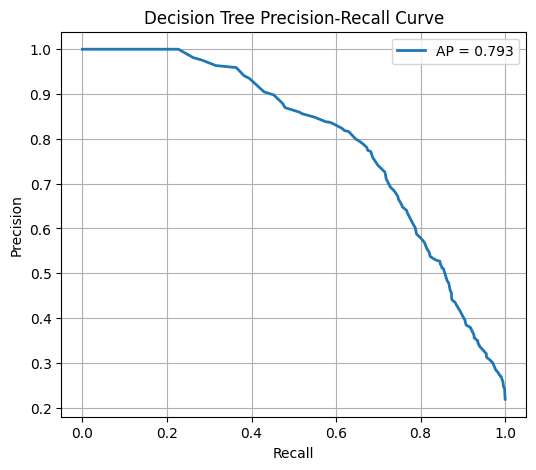

Random Forest

Classification Report

              precision    recall  f1-score      support
0              0.931733  0.980655  0.955568  5066.000000
1              0.914931  0.743300  0.820233  1418.000000
accuracy       0.928748  0.928748  0.928748     0.928748
macro avg      0.923332  0.861978  0.887901  6484.000000
weighted avg   0.928058  0.928748  0.925972  6484.000000

ROC-AUC : 0.9310
PR-AUC  : 0.8805

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4968           98
Actual 1          364         1054


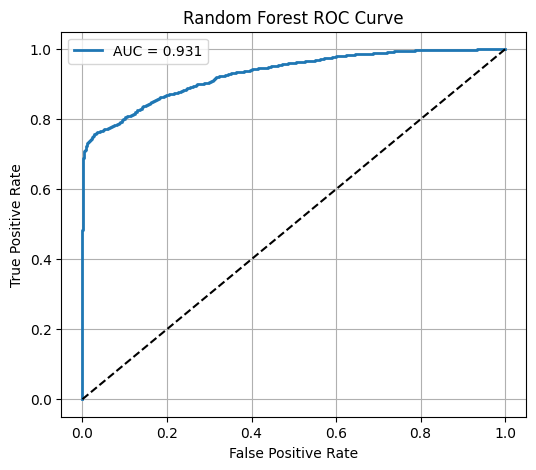

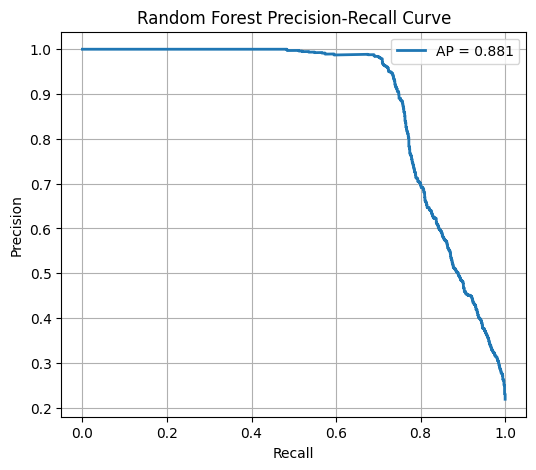

Voting Classifier

Classification Report

              precision    recall  f1-score      support
0              0.929031  0.969009  0.948599  5066.000000
1              0.869167  0.735543  0.796791  1418.000000
accuracy       0.917952  0.917952  0.917952     0.917952
macro avg      0.899099  0.852276  0.872695  6484.000000
weighted avg   0.915939  0.917952  0.915400  6484.000000

ROC-AUC : 0.9203
PR-AUC  : 0.8561

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4909          157
Actual 1          375         1043


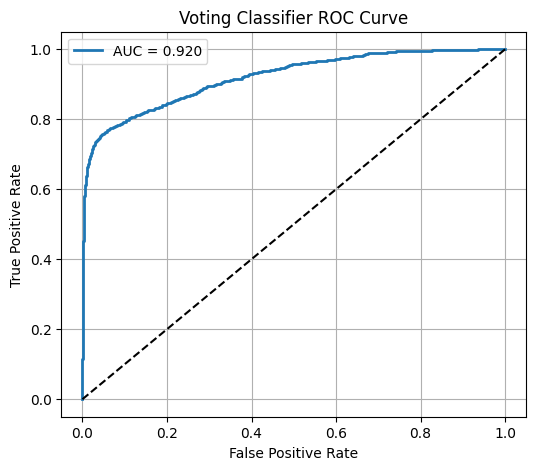

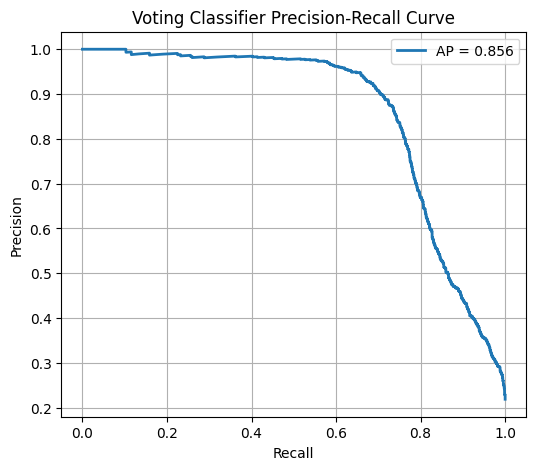

XGBoost

Classification Report

              precision    recall  f1-score      support
0              0.941927  0.976510  0.958907  5066.000000
1              0.903409  0.784908  0.840000  1418.000000
accuracy       0.934608  0.934608  0.934608     0.934608
macro avg      0.922668  0.880709  0.899453  6484.000000
weighted avg   0.933503  0.934608  0.932903  6484.000000

ROC-AUC : 0.9505
PR-AUC  : 0.9114

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4947          119
Actual 1          305         1113


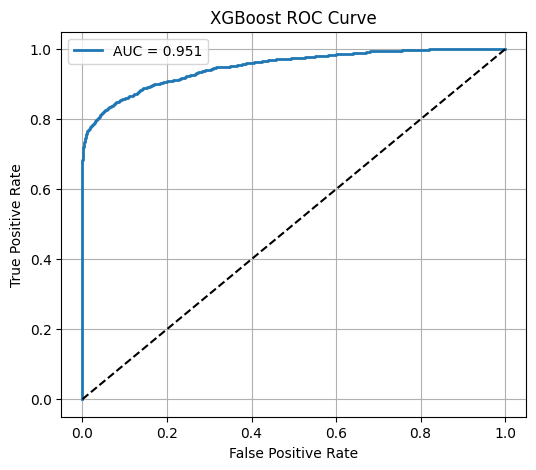

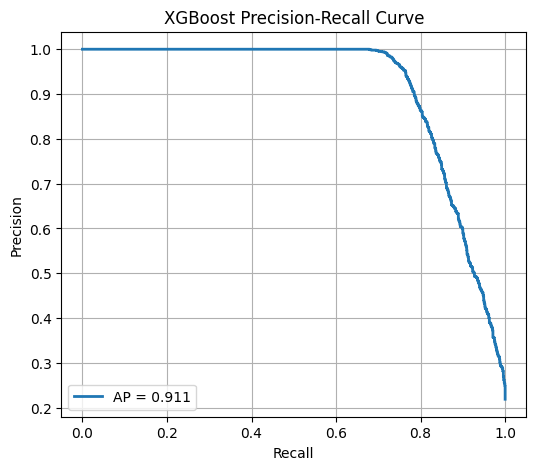

LightGBM

Classification Report

              precision    recall  f1-score      support
0              0.940907  0.974339  0.957331  5066.000000
1              0.894992  0.781382  0.834337  1418.000000
accuracy       0.932141  0.932141  0.932141     0.932141
macro avg      0.917950  0.877860  0.895834  6484.000000
weighted avg   0.930866  0.932141  0.930433  6484.000000

ROC-AUC : 0.9522
PR-AUC  : 0.9114

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4936          130
Actual 1          310         1108


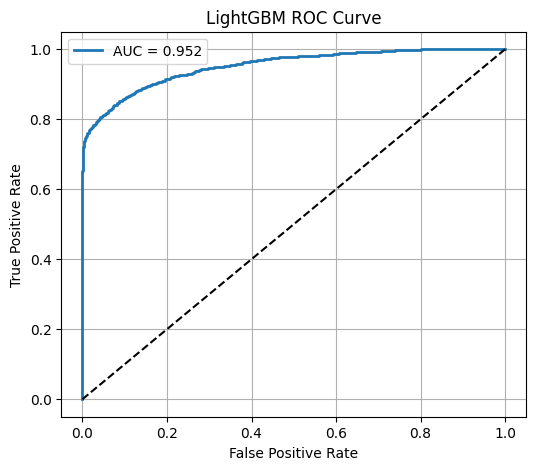

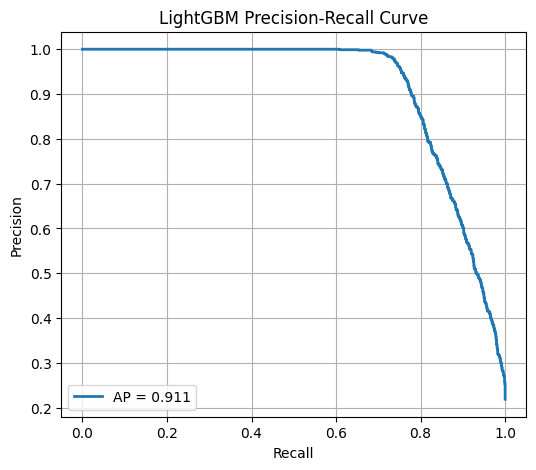

Balanced Random Forest

Classification Report

              precision    recall  f1-score      support
0              0.932940  0.966640  0.949491  5066.000000
1              0.863158  0.751763  0.803619  1418.000000
accuracy       0.919648  0.919648  0.919648     0.919648
macro avg      0.898049  0.859202  0.876555  6484.000000
weighted avg   0.917679  0.919648  0.917590  6484.000000

ROC-AUC : 0.9288
PR-AUC  : 0.8755

Confusion Matrix

          Predicted 0  Predicted 1
Actual 0         4897          169
Actual 1          352         1066


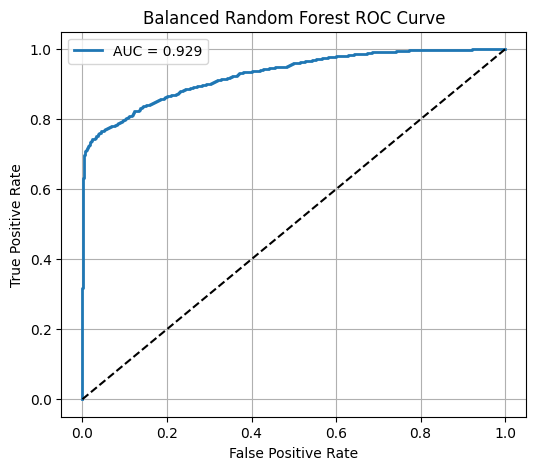

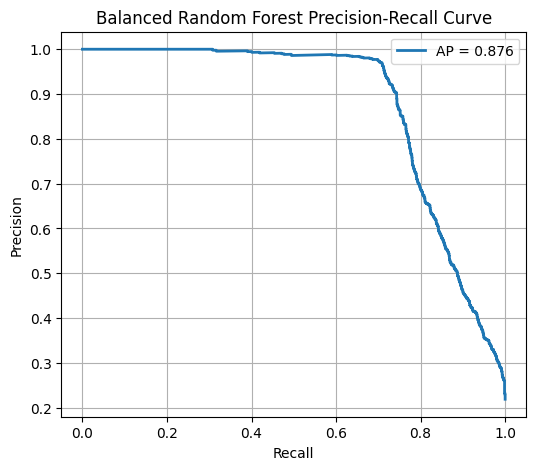

In [153]:
lr_results = evaluate_model(
    lr,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.65,
    model_name="Logistic Regression"
)

knn_results = evaluate_model(
    knn,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.50,
    model_name="KNN"
)

dt_results = evaluate_model(
    dt,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.50,
    model_name="Decision Tree"
)

rf_results = evaluate_model(
    rf,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.40,
    model_name="Random Forest"
)

voting_results = evaluate_model(
    voting,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.50,
    model_name="Voting Classifier"
)

xgb_results = evaluate_model(
    xgb,
    x_train_df1.astype(float),
    y_train,
    x_test_df1.astype(float),
    y_test,
    threshold=0.60,
    model_name="XGBoost"
)

lgbm_results = evaluate_model(
    lgbm,
    x_train_df1.astype(float),
    y_train,
    x_test_df1.astype(float),
    y_test,
    threshold=0.60,
    model_name="LightGBM"
)

brf_results = evaluate_model(
    brf,
    x_train_df1,
    y_train,
    x_test_df1,
    y_test,
    threshold=0.62,
    model_name="Balanced Random Forest"
)

In [154]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Voting Classifier",
        "XGBoost",
        "LightGBM",
        "Balanced Random Forest"
    ],

    "Accuracy": [
        lr_results["accuracy"],
        knn_results["accuracy"],
        dt_results["accuracy"],
        rf_results["accuracy"],
        voting_results["accuracy"],
        xgb_results["accuracy"],
        lgbm_results["accuracy"],
        brf_results["accuracy"]
    ],

    "Precision": [
        lr_results["precision"],
        knn_results["precision"],
        dt_results["precision"],
        rf_results["precision"],
        voting_results["precision"],
        xgb_results["precision"],
        lgbm_results["precision"],
        brf_results["precision"]
    ],

    "Recall": [
        lr_results["recall"],
        knn_results["recall"],
        dt_results["recall"],
        rf_results["recall"],
        voting_results["recall"],
        xgb_results["recall"],
        lgbm_results["recall"],
        brf_results["recall"]
    ],

    "F1 Score": [
        lr_results["f1_score"],
        knn_results["f1_score"],
        dt_results["f1_score"],
        rf_results["f1_score"],
        voting_results["f1_score"],
        xgb_results["f1_score"],
        lgbm_results["f1_score"],
        brf_results["f1_score"]
    ],

    "ROC-AUC": [
        lr_results["roc_auc"],
        knn_results["roc_auc"],
        dt_results["roc_auc"],
        rf_results["roc_auc"],
        voting_results["roc_auc"],
        xgb_results["roc_auc"],
        lgbm_results["roc_auc"],
        brf_results["roc_auc"]
    ],

    "PR-AUC": [
        lr_results["pr_auc"],
        knn_results["pr_auc"],
        dt_results["pr_auc"],
        rf_results["pr_auc"],
        voting_results["pr_auc"],
        xgb_results["pr_auc"],
        lgbm_results["pr_auc"],
        brf_results["pr_auc"]
    ]
})

comparison = comparison.round(4)

comparison.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True, inplace=True)

print(comparison)

                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0                LightGBM    0.9321     0.8950  0.7814    0.8343   0.9522   
1                 XGBoost    0.9346     0.9034  0.7849    0.8400   0.9505   
2           Random Forest    0.9287     0.9149  0.7433    0.8202   0.9310   
3  Balanced Random Forest    0.9196     0.8632  0.7518    0.8036   0.9288   
4       Voting Classifier    0.9180     0.8692  0.7355    0.7968   0.9203   
5           Decision Tree    0.8806     0.7403  0.6996    0.7194   0.8978   
6                     KNN    0.8942     0.9040  0.5776    0.7048   0.8908   
7     Logistic Regression    0.8467     0.6573  0.6248    0.6406   0.8693   

   PR-AUC  
0  0.9114  
1  0.9114  
2  0.8805  
3  0.8755  
4  0.8561  
5  0.7926  
6  0.8051  
7  0.7098  


In [155]:
comparison.to_csv("Model_Comparison.csv", index=False)

In [156]:
comparison.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    color="green"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,LightGBM,0.932100,0.895000,0.781400,0.834300,0.952200,0.911400
1,XGBoost,0.934600,0.903400,0.784900,0.840000,0.950500,0.911400
2,Random Forest,0.928700,0.914900,0.743300,0.820200,0.931000,0.880500
3,Balanced Random Forest,0.919600,0.863200,0.751800,0.803600,0.928800,0.875500
4,Voting Classifier,0.918000,0.869200,0.735500,0.796800,0.920300,0.856100
5,Decision Tree,0.880600,0.740300,0.699600,0.719400,0.897800,0.792600
6,KNN,0.894200,0.904000,0.577600,0.704800,0.890800,0.805100
7,Logistic Regression,0.846700,0.657300,0.624800,0.640600,0.869300,0.709800


# Saving top 2 models i.e LightGBM,XGBoost

In [159]:
import joblib

joblib.dump(lgbm, "lightgbm.pkl")  # saving lightgbm 
joblib.dump(xgb, "xgboost_credit_risk.pkl") # saving xgboost




['xgboost_credit_risk.pkl']

Saving Remaining models

In [160]:
joblib.dump(lr, "logistic_regression.pkl")

joblib.dump(knn, "knn.pkl")

joblib.dump(dt, "decision_tree.pkl")

joblib.dump(rf, "random_forest.pkl")

joblib.dump(voting, "voting_classifier.pkl")

joblib.dump(brf, "balanced_random_forest.pkl")

['balanced_random_forest.pkl']

# Model Comparision

The performance of all eight machine learning models was compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC to identify the most effective classifier for credit risk prediction. Logistic Regression provided a strong baseline, while K-Nearest Neighbors and Decision Tree achieved satisfactory performance but were less effective than the ensemble methods. Random Forest and the Voting Classifier improved predictive accuracy by combining multiple decision trees, demonstrating better generalization. Among all the models, XGBoost and LightGBM achieved the best overall performance, delivering superior ROC-AUC and PR-AUC scores while maintaining an excellent balance between precision and recall. The Balanced Random Forest also performed well by effectively handling class imbalance. Overall, the comparison shows that ensemble boosting techniques outperform traditional machine learning algorithms for credit risk prediction, making them the most suitable choice for accurately identifying potential loan defaults.


# Model Rankig

The performance of eight machine learning models was compared using Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC to identify the most effective classifier for credit risk prediction. Among all the models, **XGBoost** achieved the best overall performance with an Accuracy of **93.46%**, Precision of **90.34%**, Recall of **78.49%**, and F1-score of **84.00%**, while maintaining an excellent ROC-AUC of **95.05%** and PR-AUC of **91.14%**. **LightGBM** ranked second, achieving the highest ROC-AUC (**95.22%**) and the same PR-AUC as XGBoost, with performance very close to the best model. **Random Forest** and **Balanced Random Forest** also demonstrated strong predictive capability, whereas the **Voting Classifier** provided stable performance without surpassing the boosting-based models. **Decision Tree** and **K-Nearest Neighbors** produced moderate results, with KNN exhibiting high precision but comparatively low recall. **Logistic Regression** served as the baseline model and achieved the lowest overall performance. Overall, the comparison demonstrates that ensemble boosting algorithms, particularly XGBoost and LightGBM, significantly outperform traditional machine learning models for credit risk prediction by providing superior predictive accuracy and a better balance between precision and recall.



# Key Findings

* A complete machine learning pipeline was developed, covering data preprocessing, model training, evaluation, optimization, and explainability.
* Missing values were handled using median imputation with missing-value indicators, while outliers were treated using the IQR-based capping method.
* Hyperparameter optimization using Optuna improved the performance of all machine learning models.
* Probability threshold optimization enhanced the balance between precision and recall, making the models more suitable for imbalanced credit risk classification.
* Eight classification algorithms were evaluated and compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.
* LightGBM achieved the best overall performance, while XGBoost delivered the highest recall, making it highly effective at identifying potential loan defaulters.
* Random Forest and Balanced Random Forest also demonstrated strong predictive performance and good generalization capability.
* SHAP explainability identified **person income, loan grade, loan percent income, loan interest rate, and home ownership** as some of the most influential features affecting loan default prediction.
* Ensemble learning methods consistently outperformed traditional machine learning algorithms, highlighting their effectiveness for credit risk prediction.
* The developed framework provides an accurate, interpretable, and scalable solution that can assist financial institutions in assessing borrower risk and supporting better lending decisions.


# Conclusion

This project successfully developed an end-to-end machine learning framework for credit risk prediction by integrating comprehensive data preprocessing, feature engineering, hyperparameter optimization using Optuna, probability threshold optimization, and explainable AI techniques. Eight classification models were trained and evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC, with **XGBoost** achieving the best overall performance, attaining an **Accuracy of 93.46%**, **Precision of 90.34%**, **Recall of 78.49%**, **F1-score of 84.00%**, **ROC-AUC of 95.05%**, and **PR-AUC of 91.14%**. Although LightGBM achieved a marginally higher ROC-AUC, XGBoost provided the best balance between precision and recall, making it the most suitable model for predicting loan default. Furthermore, SHAP explainability and feature importance analysis identified key factors influencing credit risk, demonstrating that the proposed framework is accurate, interpretable, and capable of supporting informed lending decisions in real-world financial applications.

